# OHLC — styler settings

Companion to `candlesticks-styles.ipynb`: the `OHLC` settings hook — `ohlc.up.color` / `ohlc.down.color` (independent per-side params: kwarg → setting → `text.color`) and `ohlc.alpha` (kwarg → setting → 1.0). OHLC bars color by close vs *previous* close — the interbar criterion is the chart type's definition — one color per direction, no anatomy or mode flags.

In [1]:
from mplchart.chart import Chart
from mplchart.primitives import OHLC
from mplchart.samples import sample_prices
from mplchart.styles import available_styles, get_styler

prices = sample_prices().tail(60)
prices.tail()

,open,high,low,close,volume
date,,,,,
2025-11-11,269.809998,275.910004,269.799988,275.250000,46208300
2025-11-12,275.000000,275.730011,271.700012,273.470001,48398000
2025-11-13,274.109985,276.700012,272.089996,272.950012,49602800
2025-11-14,271.049988,275.959991,269.600006,272.410004,47399300
2025-11-17,268.815002,270.489990,265.730011,267.459991,42862157


In [2]:
def show_ohlc(prices, title, settings=(), style=None, **kwargs):
    """Plot OHLC bars under a style — a spec via style=, or a settings dict."""
    if style is None:
        style = get_styler('mplchart', overrides=settings)
    chart = Chart(prices, figsize=(12, 4), title=title, style=style)
    chart.plot(OHLC(**kwargs))
    chart.show()

## Kwargs and settings

Default is mono `text.color` bars (a classic, readable look — no direction-blind guard needed, the open/close ticks carry information). The side colors are independent params, not an atomic scheme (unlike candlesticks): each kwarg overrides only its own side's setting.

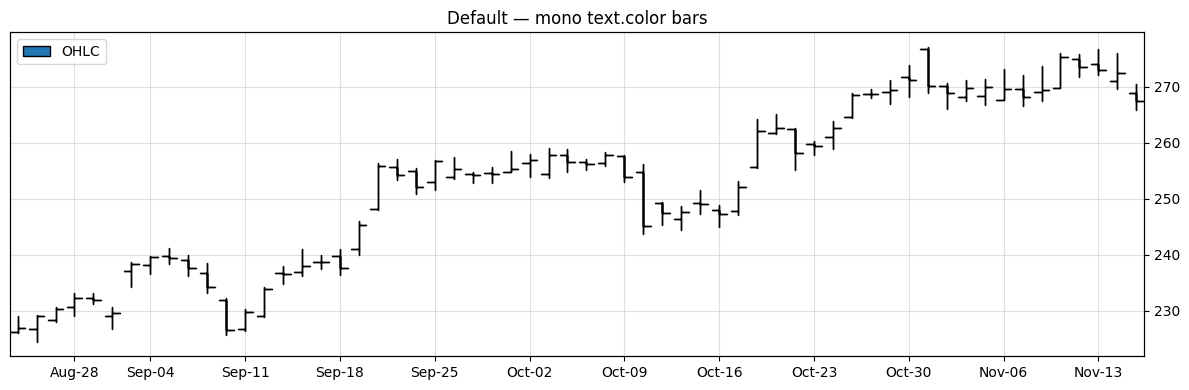

In [3]:
show_ohlc(prices, "Default — mono text.color bars")

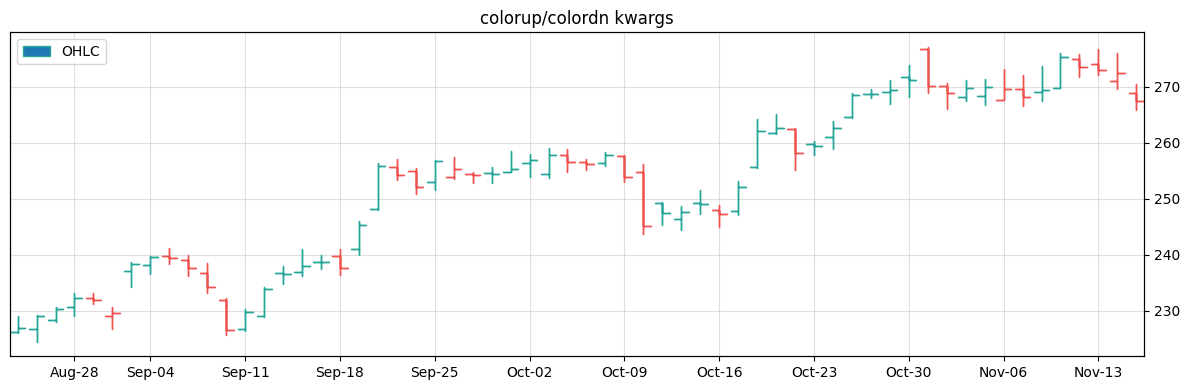

In [4]:
show_ohlc(prices, "colorup/colordn kwargs",
          colorup="#26a69a", colordn="#ef5350")

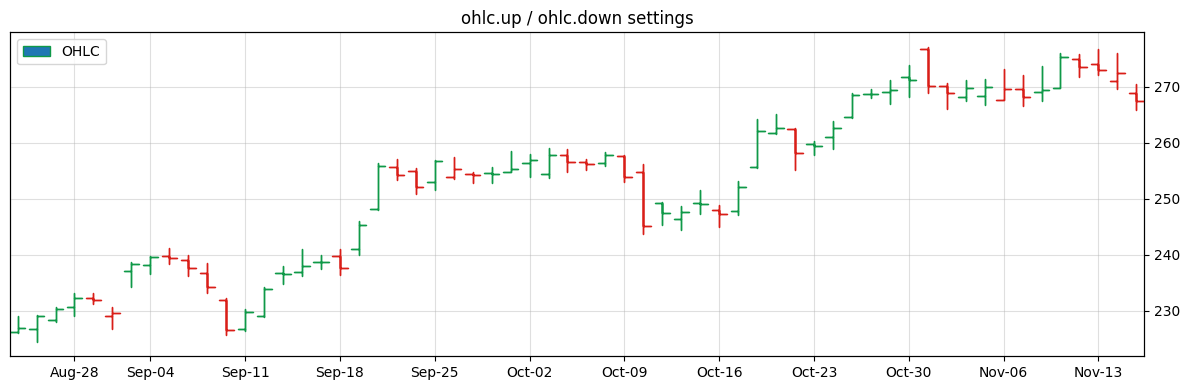

In [5]:
show_ohlc(prices, "ohlc.up / ohlc.down settings",
          {"ohlc.up.color": "#0f9948", "ohlc.down.color": "#d91e18"})

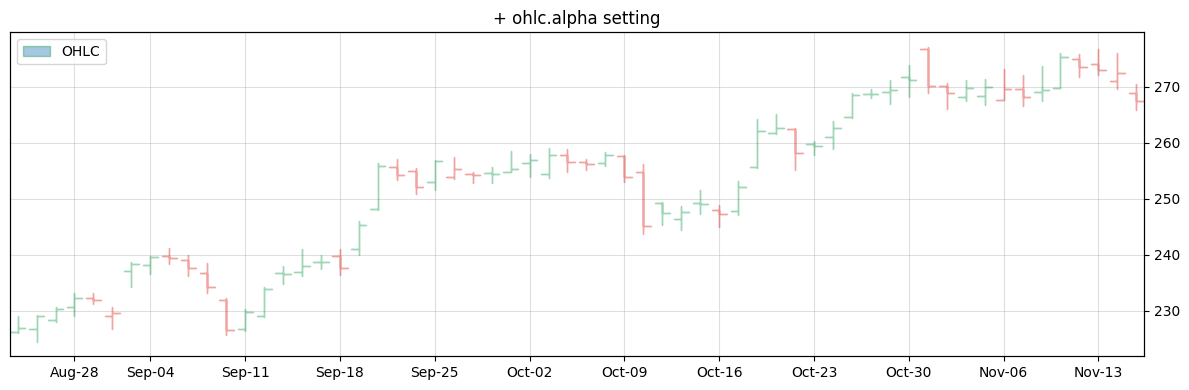

In [6]:
show_ohlc(prices, "+ ohlc.alpha setting",
          {"ohlc.up.color": "#0f9948", "ohlc.down.color": "#d91e18",
           "ohlc.alpha": 0.4})

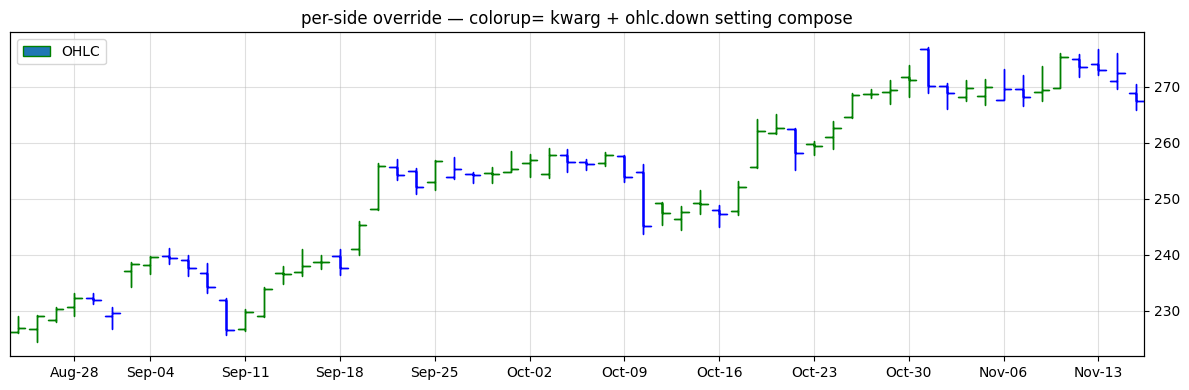

In [7]:
show_ohlc(prices, "per-side override — colorup= kwarg + ohlc.down setting compose",
          {"ohlc.down.color": "blue"}, colorup="green")

## Shipped styles

Every shipped style declares its OHLC palette alongside the candle keys (roles are independent — no `ohlc.*` → `candle.*` fallback).

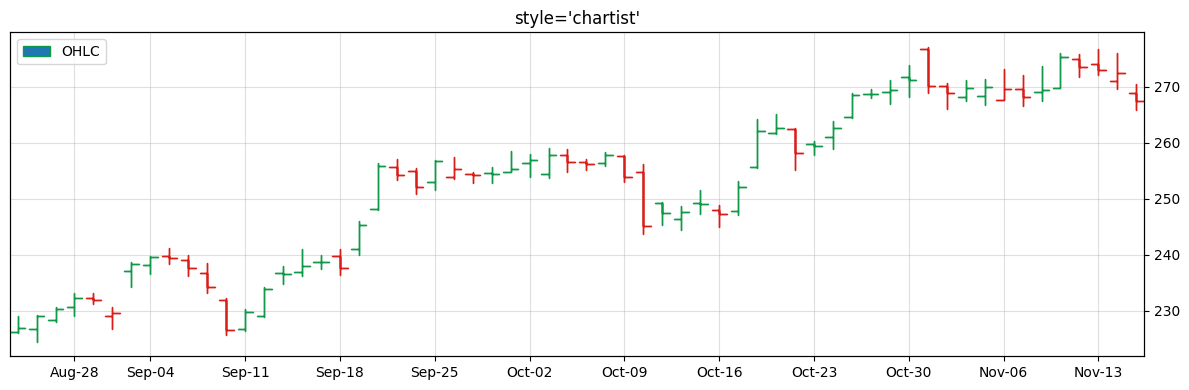

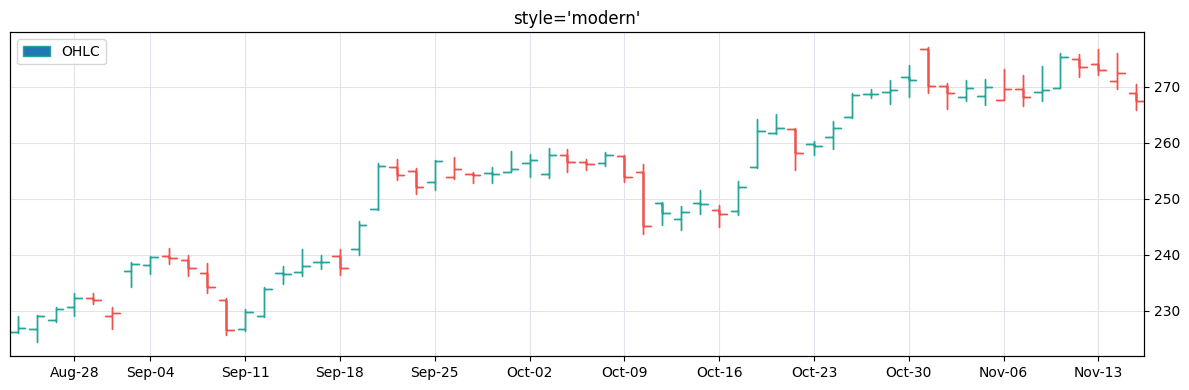

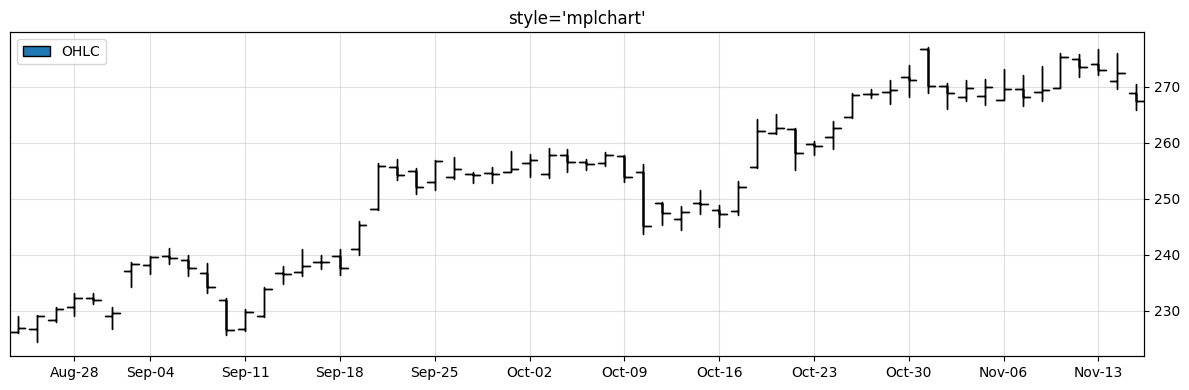

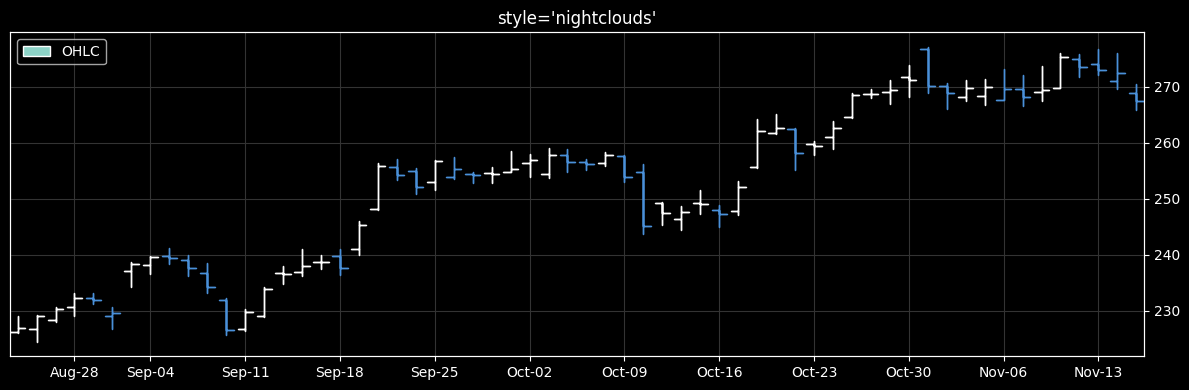

In [8]:
for name in available_styles():
    show_ohlc(prices, f"style={name!r}", style=name)